In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_heart_data.csv')

# Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Train/Test split (All members must use random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split successfully!")

Data loaded and split successfully!


In [3]:
# Create the model
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42) 
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


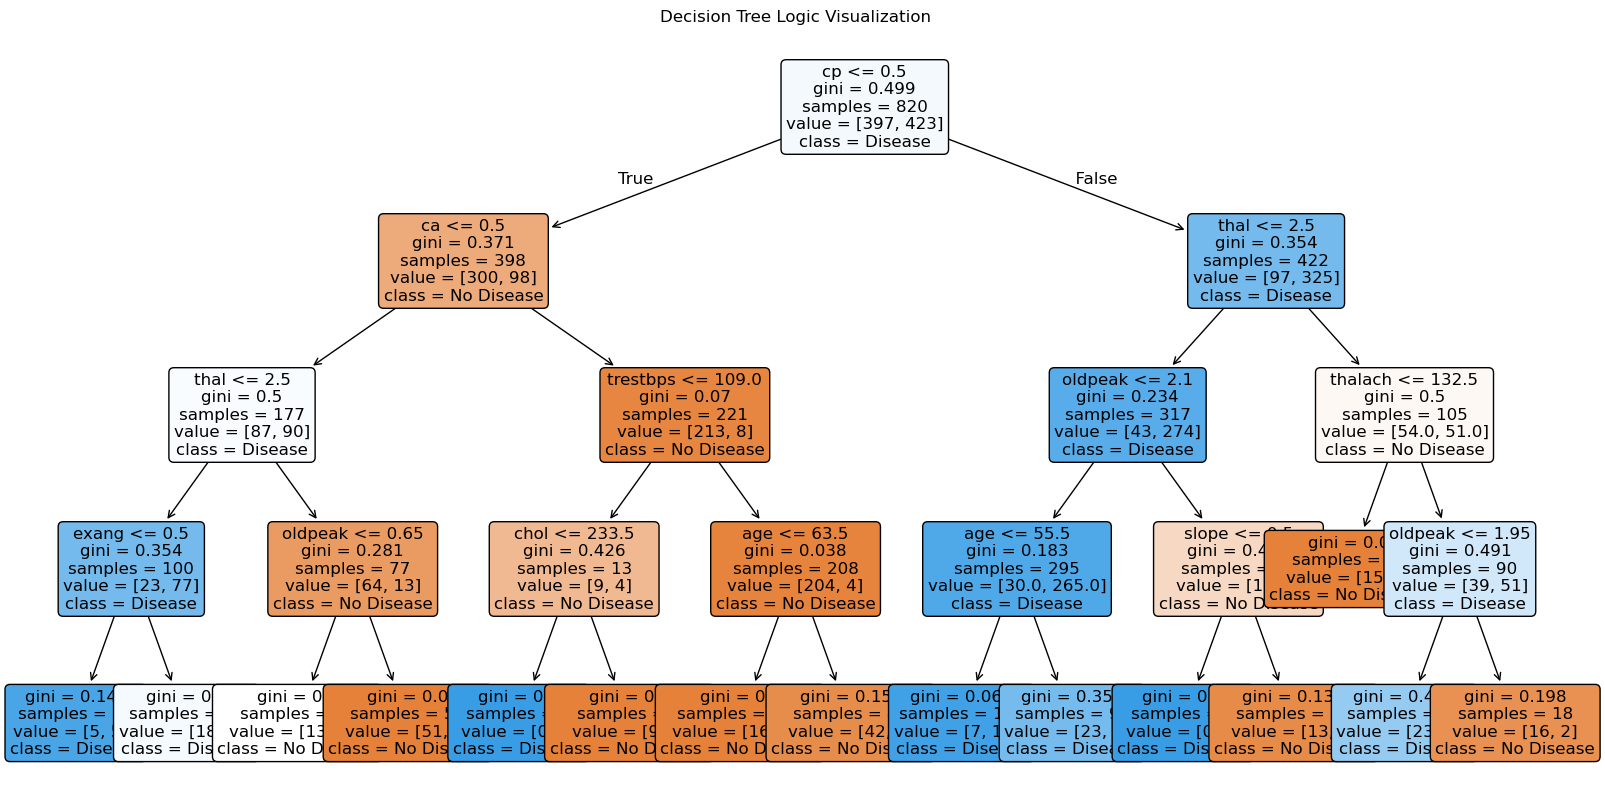

In [4]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X.columns,  
          class_names=['No Disease', 'Disease'],
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Decision Tree Logic Visualization")
plt.show()

/var/folders/ky/kn9s_pjd7d18mhz3m640wg8r0000gn/T/ipykernel_2793/693507786.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


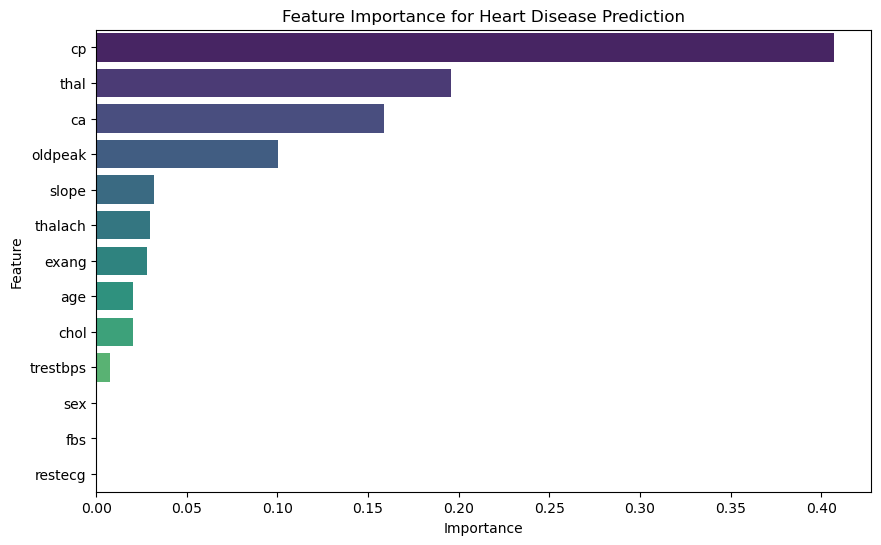

In [5]:
importances = dt_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Heart Disease Prediction')
plt.show()

--- Decision Tree Evaluation Results ---
Accuracy Score: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



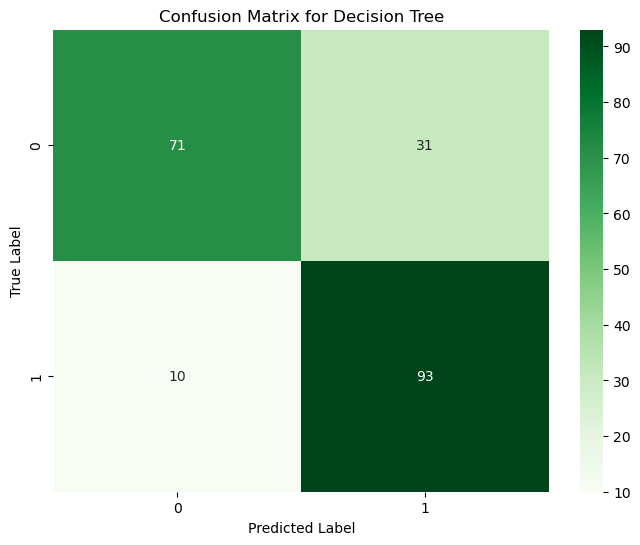

In [6]:
y_pred = dt_model.predict(X_test)

print("--- Decision Tree Evaluation Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()